# 深度学习训练技巧与超参数调优

> **💡 核心要义**：模型训练不是闭着眼睛瞎跑，超参数就像是炼丹炉的火候、风门和药引。调参的本质是重塑“误差曲面 (Error Surface)”并控制优化路径。

## 📦 1. Batch Size (批次大小)：大与小的博弈
- **概念**：每次喂给模型用于计算一次梯度的样本数量。
- **Large Batch (大批次)**：
  - *优点*：GPU 矩阵并行运算效率高，每个 epoch 跑得快；梯度更新方向稳定。
  - *缺点*：容易陷入“尖锐的局部最优 (Sharp Minima)”，导致测试集上表现很差（泛化能力弱）。
- **Small Batch (小批次) 🌟李宏毅更推荐**：
  - *优点*：每次更新带有一点随机“噪声”，这种震荡反而能帮助模型跳出局部最优，找到“平缓的峡谷 (Flat Minima)”，泛化能力更强。
  - *缺点*：GPU 并行度低，训练一个 epoch 耗时更长。

## 🏃 2. Learning Rate (学习率)：步子迈多大？
- **核心矛盾**：
  - 学习率太大 ➡️ Loss 剧烈震荡甚至发散（飞出山谷）。
  - 学习率太小 ➡️ 收敛极慢，容易死在半山腰的平缓地带 (Saddle Point) 走不动。
- **进阶解法 (自适应学习率)**：
  - 不要全局固定一个学习率！每个参数都该有自己的节奏。
  - *RMSProp / Adam*：坡度陡的地方（历史梯度大）步子变小，坡度缓的地方（历史梯度小）步子变大。
  - *Warm Up (预热)*：训练刚开始时，因为还没摸清方向，学习率先从小慢慢变大；等方向明确了，再慢慢衰减变小。

## 📏 3. Normalization (归一化/标准化)：把崎岖山地推平
- **问题**：如果输入数据的各个特征（比如 $x_1$ 范围 0-1，$x_2$ 范围 0-1000）尺度相差极大，会导致误差曲面变成一个“狭长且倾斜的椭圆谷”。在这个谷里，梯度下降会在两侧疯狂来回震荡，极难收敛。
- **Batch Normalization (批归一化)**：
  - *操作*：在输入每一层网络前，强行把一个 Batch 内的数据拉回均值为 0、方差为 1 的正态分布。
  - *效果*：把“狭长的椭圆谷”硬生生压成了“正圆形的锅底”。不管你在哪个位置，梯度的方向都直指锅底中心，可以直接开大学习率往下冲，训练速度原地起飞！

---
## 🎯 实操总结 (对比实验预期)
- **学习率实验**：LR 太大看震荡，LR 太小看停滞。
- **隐藏层宽度实验**：宽度不足看欠拟合（Train Loss 降不下去）。
- **Dropout 实验**：开启后看 Val Loss 的分离点延后（抑制过拟合）。

AssertionError: 0.8281243616739908

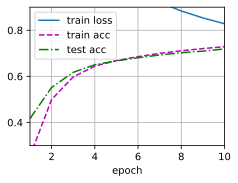

In [3]:
# 改变学习率对实验的影响
# MLP简洁实现
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.1)

net.apply(init_weights);

batch_size, lr, num_epochs = 256, 0.001, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

AssertionError: 2.2619483408610024

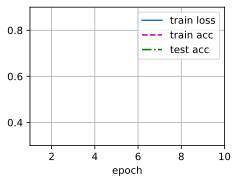

In [4]:
# MLP简洁实现
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.1)

net.apply(init_weights);

batch_size, lr, num_epochs = 256, 1.5, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

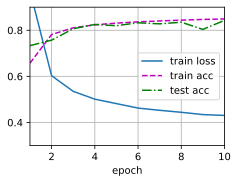

In [ ]:
# 弱智网络
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 16),
                    nn.ReLU(),
                    nn.Linear(16, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.1)

net.apply(init_weights);

batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

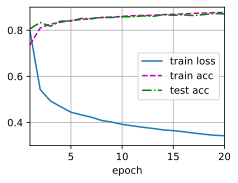

In [8]:
# MLP简洁实现
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 512),
                    nn.ReLU(),
                    nn.Dropout(0.5),
                    nn.Linear(512, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.1)

net.apply(init_weights);

batch_size, lr, num_epochs = 256, 0.1, 20
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)